# Los Angeles Lakers 2023-24

## 1. Abstracto, motivación y audiencia.

El objetivo de este proyecto es analizar el rendimiento de Los Angeles Lakers durante la temporada regular 2023-24. La motivación es entender qué factores estadísticos (como acierto de triples, rebotes o asistencias) impactan más en las victorias. Este análisis está dirigido a analistas deportivos y cuerpos técnicos que buscan optimizar estrategias de juego basadas en datos.

## 2. Preguntas/hipótesis que queremos responder

Definimos 3 preguntas  que despues vamos a contestar con gráficos en la última parte:

* ¿Existe una relación directa entre la cantidad de asistencias de los
Lakers y la probabilidad de ganar el partido?

* ¿Cómo afecta el porcentaje de acierto de tiros de campo (Field Goals %) en el resultado final?

* ¿El equipo rinde estadísticamente mejor jugando de local o de visitante?

## 3. Importación de datos y guardado

Primero instalamos la libreria nba_api.

Despues traemos los datos de la API y creamos el archivo local.

In [6]:
!pip install nba_api

In [7]:
# Importamos las librerías necesarias
from nba_api.stats.endpoints import leaguegamefinder
import pandas as pd

# 1. Traemos los partidos de Los Angeles Lakers (ID: 1610612747)
# Filtramos por la temporada regular 2023-24
gamefinder = leaguegamefinder.LeagueGameFinder(
    team_id_nullable=1610612747,
    season_nullable='2023-24',
    season_type_nullable='Regular Season'
)

# 2. Convertimos la respuesta de la API a un DataFrame de Pandas
df_lakers = gamefinder.get_data_frames()[0]

# 3. Guardamos los datos crudos en un archivo local CSV
df_lakers.to_csv('lakers_23_24_crudo.csv', index=False)

print("¡Datos descargados y guardados en 'lakers_23_24_crudo.csv'!")
print(f"Se descargaron {len(df_lakers)} partidos con {df_lakers.shape[1]} variables cada uno.")

df_lakers = pd.read_csv('lakers_23_24_crudo.csv')

¡Datos descargados y guardados en 'lakers_23_24_crudo.csv'!
Se descargaron 82 partidos con 28 variables cada uno.


## 4. Análisis exploratorio de datos - EDA

Una vez que tengamos ese CSV, pasamos a la última etapa: limpiar un poco los datos (quedarnos con las columnas que nos sirven, como Puntos, Asistencias, Resultado) y hacer los gráficos (con librerías como matplotlib o seaborn) para responder las tres preguntas que nos planteamos arriba.

Ahora vamos a hacerle una minima transformación al csv, para saber si jugaron de local o visitante y armar tres gráficos profesionales que responden directamente las tres hipótesis anteriormente planteadas.

In [8]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Cargamos los datos limpios desde el archivo local
df_lakers = pd.read_csv('lakers_23_24_crudo.csv')

# 2. Limpieza y Transformación (Feature Engineering)
# La columna 'MATCHUP' dice contra quién jugaron.
# Si tiene un '@', fueron visitantes. Si tiene 'vs.', fueron locales.
df_lakers['Localia'] = df_lakers['MATCHUP'].apply(lambda x: 'Visitante' if '@' in x else 'Local')

# Limpiamos posibles valores nulos en la columna de victorias/derrotas (WL)
df_lakers = df_lakers.dropna(subset=['WL'])

# Configuramos un estilo visual elegante para los gráficos
sns.set_theme(style="whitegrid")
# Usamos los colores oficiales de los Lakers para darle una personalizacion especial (Morado y Amarillo)
lakers_colors = ['#552583', '#FDB927']

/tmp/ipykernel_10687/999274616.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='WL', y='AST', data=df_lakers, palette=lakers_colors, order=['W', 'L'])


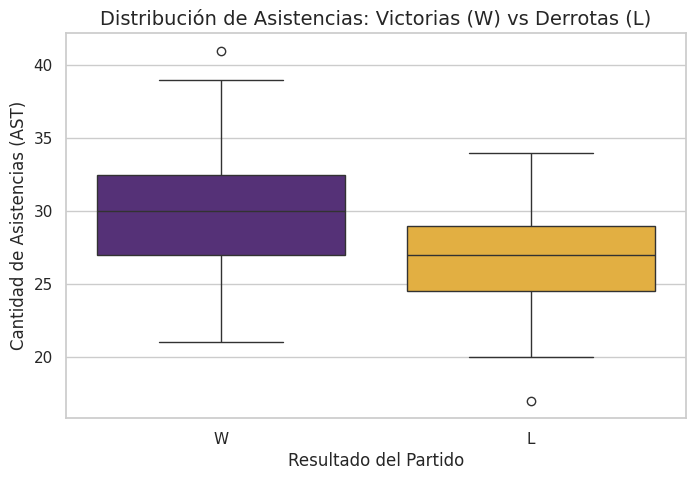

In [9]:
# ==========================================
# Gráfico 1: Asistencias vs Probabilidad de ganar
# ==========================================
plt.figure(figsize=(8, 5))
sns.boxplot(x='WL', y='AST', data=df_lakers, palette=lakers_colors, order=['W', 'L'])
plt.title('Distribución de Asistencias: Victorias (W) vs Derrotas (L)', fontsize=14)
plt.xlabel('Resultado del Partido', fontsize=12)
plt.ylabel('Cantidad de Asistencias (AST)', fontsize=12)
plt.show()



---



/tmp/ipykernel_10687/3126717972.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='WL', y='FG_PCT', data=df_lakers, palette=lakers_colors, order=['W', 'L'])


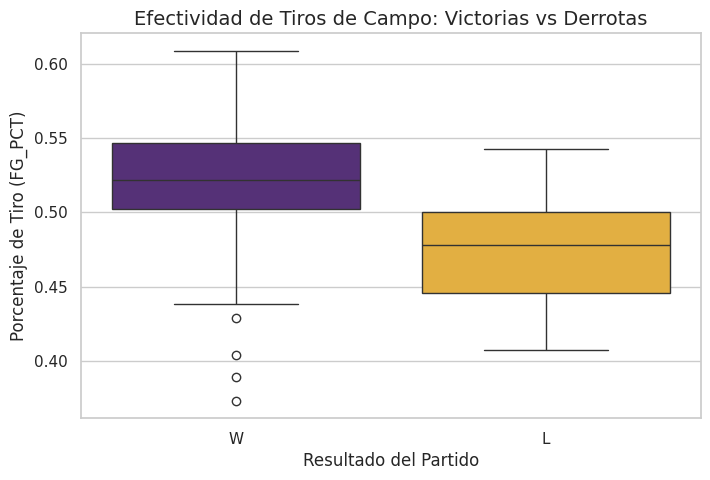

In [10]:
# ==========================================
# Gráfico 2: Efectividad de Tiro (FG%) vs Resultado
# ==========================================
plt.figure(figsize=(8, 5))
sns.boxplot(x='WL', y='FG_PCT', data=df_lakers, palette=lakers_colors, order=['W', 'L'])
plt.title('Efectividad de Tiros de Campo: Victorias vs Derrotas', fontsize=14)
plt.xlabel('Resultado del Partido', fontsize=12)
plt.ylabel('Porcentaje de Tiro (FG_PCT)', fontsize=12)
plt.show()



---



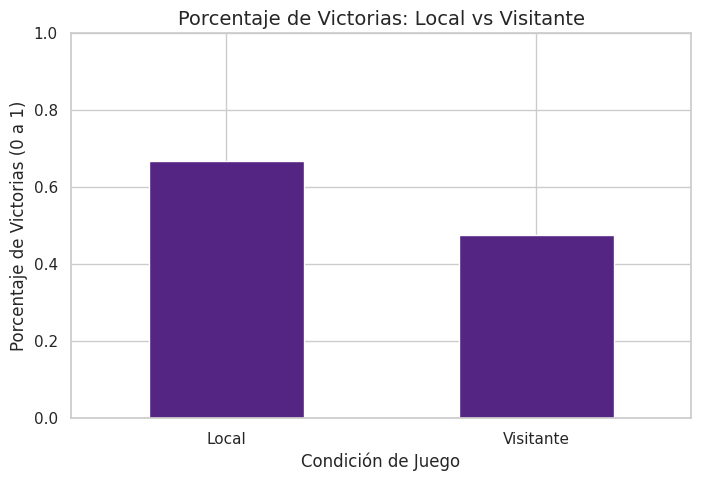

In [11]:
# ==========================================
# Gráfico 3: Rendimiento Local vs Visitante
# ==========================================
plt.figure(figsize=(8, 5))
# Calculamos el % de victorias agrupando por localía
win_rates = df_lakers.groupby('Localia')['WL'].value_counts(normalize=True).unstack()

# Graficamos solo la columna de Victorias ('W')
win_rates['W'].plot(kind='bar', color='#552583', figsize=(8, 5))
plt.title('Porcentaje de Victorias: Local vs Visitante', fontsize=14)
plt.xlabel('Condición de Juego', fontsize=12)
plt.ylabel('Porcentaje de Victorias (0 a 1)', fontsize=12)
plt.xticks(rotation=0)
plt.ylim(0, 1)
plt.show()



---



## 5. Conclusiones y Hallazgos Principales

Analizando los datos de los Lakers en la temporada regular 2023-24, encontramos tres puntos clave que marcan la diferencia entre ganar y perder:

* **El juego en equipo pesa más que las individualidades:** Los gráficos muestran que en las victorias, el equipo registra muchas más asistencias. Mover la pelota y buscar al compañero libre es fundamental para llevarnos el partido.

* **Calidad de tiro sobre cantidad:** La diferencia de efectividad (FG%) entre los partidos ganados y perdidos es gigante. El equipo rinde muchísimo mejor cuando tiene paciencia y selecciona tiros cómodos o seguros, en lugar de forzar jugadas difíciles.


* **La importancia de nuestra cancha:** Los números no mienten, el porcentaje de victorias jugando de local es notablemente superior. Esto nos demuestra que asegurar los partidos en casa (en el Crypto.com Arena) es nuestra principal fortaleza para llegar bien posicionados a los Playoffs.